<a href="https://www.kaggle.com/code/izzarsulynashrudin/idscbrugadahucasynthesis?scriptVersionId=309697540" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Brugada-HUCA Using Data Synthesis

In [1]:
!pip -q install wfdb xgboost scipy scikit-learn imbalanced-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.4 MB/s eta 0:00:00


In [2]:
import os
import gc
import json
import re
import math
import random
import warnings
from tqdm.auto import tqdm
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from scipy import signal
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
import copy
import matplotlib.pyplot as plt

In [3]:

try:
    import wfdb
except Exception as e:
    wfdb = None
    print("wfdb is not available:", e)

try:
    from xgboost import XGBClassifier
except Exception as e:
    XGBClassifier = None
    print("xgboost is not available:", e)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except Exception as e:
    torch = None
    nn = None
    Dataset = object
    DataLoader = None
    print("torch is not available:", e)

## 1. Paths and Columns

In [4]:
CONFIG = {
    "original_metadata_path": "/kaggle/input/datasets/izzarsulynashrudin/brugada-huca/metadata.csv",
    "original_records_root": "/kaggle/input/datasets/izzarsulynashrudin/brugada-huca/files/files",

    "synthetic_metadata_path": "/kaggle/input/notebooks/izzarsulynashrudin/datasynthesisbrugada/brugada-huca-synthetic-gan/metadata.csv",
    "synthetic_records_root": "/kaggle/input/notebooks/izzarsulynashrudin/datasynthesisbrugada/brugada-huca-synthetic-gan/files",

    "id_col": "patient_id",
    "label_col_original": "brugada",
    "label_col_synthetic": "brugada",
    "fs": 100,
    "n_leads": 12,
    "signal_length": 1200,

    "median_pre_r": 0.25,
    "median_post_r": 0.45,
    "peak_lead": 1,
    "min_peak_distance_sec": 0.45,

    "synthetic_test_count": 363,
    "synthetic_dev_train_ratio": 90,
    "synthetic_dev_val_ratio": 5,
    "original_train_ratio": 0.95,
    "original_val_ratio": 0.05,
}
CONFIG

CONFIG.update({
    "output_root": "/kaggle/working/",
    "run_name": "cross_domain_benchmark",
})


In [5]:
OUTPUT_ROOT = Path(CONFIG["output_root"])
RUN_ROOT = OUTPUT_ROOT / CONFIG.get("run_name", "run")
PLOTS_DIR = RUN_ROOT / "plots"
TABLES_DIR = RUN_ROOT / "tables"
HISTORIES_DIR = RUN_ROOT / "histories"
METADATA_DIR = RUN_ROOT / "metadata"

for p in [OUTPUT_ROOT, RUN_ROOT, PLOTS_DIR, TABLES_DIR, HISTORIES_DIR, METADATA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def slugify(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")

def save_dataframe_outputs(df: pd.DataFrame, name: str, subdir: Optional[Path] = None) -> Dict[str, str]:
    base_dir = Path(subdir) if subdir is not None else TABLES_DIR
    base_dir.mkdir(parents=True, exist_ok=True)
    stem = slugify(name)
    csv_path = base_dir / f"{stem}.csv"
    json_path = base_dir / f"{stem}.json"
    df.to_csv(csv_path, index=False)
    df.to_json(json_path, orient="records", indent=2)
    print(f"Saved table: {csv_path}")
    print(f"Saved table: {json_path}")
    return {"csv": str(csv_path), "json": str(json_path)}

def save_text_output(text: str, name: str, subdir: Optional[Path] = None) -> str:
    base_dir = Path(subdir) if subdir is not None else METADATA_DIR
    base_dir.mkdir(parents=True, exist_ok=True)
    txt_path = base_dir / f"{slugify(name)}.txt"
    txt_path.write_text(str(text), encoding="utf-8")
    print(f"Saved text: {txt_path}")
    return str(txt_path)

def save_history_bundle(histories: Dict[str, Optional[pd.DataFrame]], prefix: str):
    saved = {}
    for model_name, hist_df in histories.items():
        if isinstance(hist_df, pd.DataFrame) and len(hist_df):
            out_name = f"{prefix}_{model_name}_history"
            saved[model_name] = save_dataframe_outputs(hist_df, out_name, subdir=HISTORIES_DIR)
    return saved

save_text_output(
    "\n".join([
        f"Output root: {OUTPUT_ROOT}",
        f"Run root: {RUN_ROOT}",
        f"Plots dir: {PLOTS_DIR}",
        f"Tables dir: {TABLES_DIR}",
        f"Histories dir: {HISTORIES_DIR}",
        f"Metadata dir: {METADATA_DIR}",
    ]),
    "output_locations",
)
print(f"All outputs will be saved under: {RUN_ROOT}")

(Path(METADATA_DIR) / "config_snapshot.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")
print(f"Saved config: {METADATA_DIR / 'config_snapshot.json'}")


Saved text: /kaggle/working/cross_domain_benchmark/metadata/output_locations.txt
All outputs will be saved under: /kaggle/working/cross_domain_benchmark
Saved config: /kaggle/working/cross_domain_benchmark/metadata/config_snapshot.json


## 2. Helpers: Labels, Splits, and Metadata Loading

In [6]:
def normalize_binary_label(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    return (s > 0).astype(int)

def resolve_metadata_column(
    df: pd.DataFrame,
    preferred: Optional[str],
    fallbacks: List[str],
    source_name: str,
    column_kind: str,
) -> str:
    ordered_candidates = []
    for col in [preferred, *fallbacks]:
        if col and col not in ordered_candidates:
            ordered_candidates.append(col)

    for col in ordered_candidates:
        if col in df.columns:
            return col

    raise ValueError(
        f"{column_kind} column was not found in {source_name} metadata. "
        f"Checked candidates: {ordered_candidates}. "
        f"Available columns: {list(df.columns)}"
    )

def resolve_id_column(df: pd.DataFrame, config: dict, source_name: str) -> str:
    return resolve_metadata_column(
        df=df,
        preferred=config.get("id_col"),
        fallbacks=["patient_id", "record_id", "id", "signal_id"],
        source_name=source_name,
        column_kind="id",
    )

def resolve_label_column(df: pd.DataFrame, config: dict, source_name: str) -> str:
    if source_name == "original":
        preferred = config.get("label_col_original")
        fallbacks = ["brugada", "label", "target", "class", "y"]
    else:
        preferred = config.get("label_col_synthetic")
        fallbacks = ["label", "brugada", "target", "class", "y"]

    return resolve_metadata_column(
        df=df,
        preferred=preferred,
        fallbacks=fallbacks,
        source_name=source_name,
        column_kind="label",
    )

def _dedupe_paths(paths: List[Path]) -> List[Path]:
    seen = set()
    out = []
    for path in paths:
        if path is None:
            continue
        key = str(path)
        if key not in seen:
            seen.add(key)
            out.append(path)
    return out

def _candidate_dataset_roots(configured_path: str) -> List[Path]:
    raw = Path(str(configured_path))
    roots = []

    if raw.suffix:
        roots.append(raw.parent)
        if raw.parent.name:
            roots.append(Path("/kaggle/input") / raw.parent.name)
        if len(raw.parts) >= 2:
            roots.append(Path("/kaggle/input") / raw.parts[-2])
    else:
        roots.append(raw)
        if raw.name:
            roots.append(Path("/kaggle/input") / raw.name)

    roots.append(Path("/kaggle/input"))
    return _dedupe_paths(roots)

def _pick_metadata_candidate(paths: List[Path], config: dict, source_name: str) -> Optional[Path]:
    if source_name == "original":
        label_candidates = [config.get("label_col_original"), "brugada", "label", "target", "class", "y"]
    else:
        label_candidates = [config.get("label_col_synthetic"), "label", "brugada", "target", "class", "y"]
    id_candidates = [config.get("id_col"), "patient_id", "record_id", "id", "signal_id"]

    scored = []
    for path in paths:
        try:
            head = pd.read_csv(path, nrows=5)
        except Exception:
            continue

        columns = set(head.columns)
        score = 0
        if any(col in columns for col in label_candidates if col):
            score += 3
        if any(col in columns for col in id_candidates if col):
            score += 3
        if "metadata" in path.name.lower():
            score += 2
        if source_name in path.name.lower():
            score += 1
        scored.append((score, str(path), path))

    if not scored:
        return None

    scored.sort(key=lambda item: (-item[0], item[1]))
    return scored[0][2]

def resolve_metadata_path(config: dict, source_name: str) -> str:
    key = f"{source_name}_metadata_path"
    configured_path = Path(str(config[key]))

    if configured_path.is_file():
        return str(configured_path)

    raise FileNotFoundError(
        f"Metadata {source_name} tidak ditemukan di path yang diberikan: {configured_path}"
    )

def resolve_records_root(config: dict, source_name: str, metadata_path: Optional[str] = None) -> str:
    key = f"{source_name}_records_root"
    configured_path = Path(str(config[key]))

    if configured_path.is_dir():
        return str(configured_path)

    raise FileNotFoundError(
        f"Root sinyal {source_name} tidak ditemukan di path yang diberikan: {configured_path}"
    )
def load_original_metadata(config: dict) -> pd.DataFrame:
    metadata_path = resolve_metadata_path(config, source_name="original")
    resolve_records_root(config, source_name="original", metadata_path=metadata_path)
    df = pd.read_csv(metadata_path)
    df = df.copy()

    resolved_id_col = resolve_id_column(df, config, source_name="original")
    resolved_label_col = resolve_label_column(df, config, source_name="original")

    df[config["id_col"]] = df[resolved_id_col].astype(str)
    df["label"] = normalize_binary_label(df[resolved_label_col])
    df["source"] = "original"
    return df

def load_synthetic_metadata(config: dict) -> pd.DataFrame:
    metadata_path = resolve_metadata_path(config, source_name="synthetic")
    resolve_records_root(config, source_name="synthetic", metadata_path=metadata_path)
    df = pd.read_csv(metadata_path)
    df = df.copy()

    resolved_label_col = resolve_label_column(df, config, source_name="synthetic")
    resolved_id_col = resolve_id_column(df, config, source_name="synthetic")

    df[config["id_col"]] = df[resolved_id_col].astype(str)
    df["label"] = normalize_binary_label(df[resolved_label_col])
    df["source"] = "synthetic"
    return df

def read_metadata(path: str, source_name: str, config: Optional[dict] = None) -> pd.DataFrame:
    source_name = str(source_name).strip().lower()
    if source_name not in {"original", "synthetic"}:
        raise ValueError("source_name must be 'original' or 'synthetic'.")

    cfg = dict(CONFIG if config is None else config)
    cfg[f"{source_name}_metadata_path"] = path

    if source_name == "original":
        return load_original_metadata(cfg)
    return load_synthetic_metadata(cfg)

def show_class_balance(df: pd.DataFrame, name: str = "dataset"):
    out = (
        df["label"]
        .value_counts(dropna=False)
        .rename_axis("label")
        .reset_index(name="count")
        .sort_values("label")
    )
    out["ratio"] = out["count"] / len(df)
    print(f"\n{name} | n={len(df)}")
    display(out)

## 3. Scenario Splits

In [7]:
@dataclass
class ScenarioSplit:
    train_df: pd.DataFrame
    val_df: pd.DataFrame
    test_df: pd.DataFrame

def summarize_split(split: ScenarioSplit, title: str):
    print(f"\n===== {title} =====")
    for name, part in [("train", split.train_df), ("val", split.val_df), ("test", split.test_df)]:
        counts = part["label"].value_counts().sort_index().to_dict()
        print(f"{name:>5}: n={len(part):>5} | class_counts={counts}")

def split_synthetic_dev_test(df_syn: pd.DataFrame, config: dict):
    requested_test_count = int(config["synthetic_test_count"])
    train_ratio = float(config["synthetic_dev_train_ratio"])
    val_ratio = float(config["synthetic_dev_val_ratio"])
    val_fraction_within_dev = val_ratio / (train_ratio + val_ratio)

    labels = df_syn["label"]
    n_classes = labels.nunique()

    min_dev_count = max(
        2 * n_classes,
        math.ceil(n_classes / max(val_fraction_within_dev, 1e-8))
    )
    max_test_count = len(df_syn) - min_dev_count

    if max_test_count < n_classes:
        raise ValueError(
            "The synthetic dataset is too small to create a stratified train/val/test split. "
            f"n={len(df_syn)}, n_classes={n_classes}, at least {min_dev_count + n_classes} samples are required."
        )

    test_count = min(requested_test_count, max_test_count)
    if test_count < requested_test_count:
        warnings.warn(
            f"synthetic_test_count={requested_test_count} is too large for n={len(df_syn)}. "
            f"Using test_count={test_count} so the dev/train/val split remains valid."
        )

    if test_count < n_classes:
        raise ValueError(
            f"The test size ({test_count}) is smaller than the number of classes ({n_classes}); "
            "a stratified split cannot be created."
        )

    dev_df, synthetic_test_df = train_test_split(
        df_syn,
        test_size=test_count,
        stratify=labels,
        random_state=SEED,
    )

    val_count = max(n_classes, int(round(len(dev_df) * val_fraction_within_dev)))
    val_count = min(val_count, len(dev_df) - n_classes)

    if val_count < n_classes or (len(dev_df) - val_count) < n_classes:
        raise ValueError(
            f"The dev pool is too small for a stratified train/val split: "
            f"n_dev={len(dev_df)}, val_count={val_count}, n_classes={n_classes}."
        )

    synthetic_train_df, synthetic_val_df = train_test_split(
        dev_df,
        test_size=val_count,
        stratify=dev_df["label"],
        random_state=SEED,
    )

    return (
        synthetic_train_df.reset_index(drop=True),
        synthetic_val_df.reset_index(drop=True),
        synthetic_test_df.reset_index(drop=True),
    )

def make_synthetic_to_original_split(
    synthetic_train_df: pd.DataFrame,
    synthetic_val_df: pd.DataFrame,
    original_test_df: pd.DataFrame,
) -> ScenarioSplit:
    return ScenarioSplit(
        train_df=synthetic_train_df.reset_index(drop=True),
        val_df=synthetic_val_df.reset_index(drop=True),
        test_df=original_test_df.reset_index(drop=True),
    )

def make_original_to_synthetic_split(
    df_org: pd.DataFrame,
    synthetic_test_df: pd.DataFrame,
    config: dict,
) -> ScenarioSplit:
    train_df, val_df = train_test_split(
        df_org,
        test_size=float(config["original_val_ratio"]),
        stratify=df_org["label"],
        random_state=SEED,
    )

    return ScenarioSplit(
        train_df=train_df.reset_index(drop=True),
        val_df=val_df.reset_index(drop=True),
        test_df=synthetic_test_df.reset_index(drop=True),
    )


df_org = load_original_metadata(CONFIG)
df_syn = load_synthetic_metadata(CONFIG)

show_class_balance(df_org, "Original dataset")
show_class_balance(df_syn, "Synthetic dataset")

synthetic_train_df, synthetic_val_df, synthetic_test_df = split_synthetic_dev_test(df_syn, CONFIG)

syn2org_split = make_synthetic_to_original_split(
    synthetic_train_df=synthetic_train_df,
    synthetic_val_df=synthetic_val_df,
    original_test_df=df_org,
)

org2syn_split = make_original_to_synthetic_split(
    df_org=df_org,
    synthetic_test_df=synthetic_test_df,
    config=CONFIG,
)

SCENARIO_SYN2ORG = "Syn2Org"
SCENARIO_ORG2SYN = "Org2Syn"

summarize_split(syn2org_split, SCENARIO_SYN2ORG)
summarize_split(org2syn_split, SCENARIO_ORG2SYN)



Original dataset | n=363


,label,count,ratio
0,0,287,0.790634
1,1,76,0.209366



Synthetic dataset | n=6897


,label,count,ratio
0,0,5478,0.794258
1,1,1419,0.205742



===== Syn2Org =====
train: n= 6190 | class_counts={0: 4917, 1: 1273}
  val: n=  344 | class_counts={0: 273, 1: 71}
 test: n=  363 | class_counts={0: 287, 1: 76}

===== Org2Syn =====
train: n=  344 | class_counts={0: 272, 1: 72}
  val: n=   19 | class_counts={0: 15, 1: 4}
 test: n=  363 | class_counts={0: 288, 1: 75}


## 4. ECG Loading and Median Beat

In [8]:
LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

def butter_bandpass_filter(x: np.ndarray, fs: int, low=0.5, high=40.0, order=4) -> np.ndarray:
    nyq = 0.5 * fs
    b, a = signal.butter(order, [low/nyq, high/nyq], btype="band")
    return signal.filtfilt(b, a, x)

def preprocess_ecg(sig: np.ndarray, fs: int) -> np.ndarray:
    sig = np.asarray(sig, dtype=np.float32)
    if sig.ndim != 2:
        raise ValueError(f"Signal must be 2D, got shape={sig.shape}")
    if sig.shape[0] == len(LEAD_NAMES) and sig.shape[1] != len(LEAD_NAMES):
        sig = sig.T 
    if sig.shape[1] != len(LEAD_NAMES):
        raise ValueError(f"Lead count mismatch. Shape after normalization: {sig.shape}")

    out = np.zeros_like(sig, dtype=np.float32)
    for i in range(sig.shape[1]):
        xi = sig[:, i]
        xf = butter_bandpass_filter(xi, fs=fs)
        x_min, x_max = xf.min(), xf.max()
        if x_max - x_min < 1e-8:
            out[:, i] = 0.0
        else:
            out[:, i] = (xf - x_min) / (x_max - x_min)
    return out

def detect_r_peaks(ecg_1lead: np.ndarray, fs: int, min_peak_distance_sec: float = 0.45) -> np.ndarray:
    distance = max(1, int(fs * min_peak_distance_sec))
    prominence = max(0.05, np.std(ecg_1lead) * 0.5)
    peaks, _ = signal.find_peaks(ecg_1lead, distance=distance, prominence=prominence)
    return peaks

def extract_median_beat(sig: np.ndarray, fs: int, peak_lead: int, pre_r_sec: float, post_r_sec: float) -> np.ndarray:
    ecg_lead = sig[:, peak_lead]
    peaks = detect_r_peaks(ecg_lead, fs=fs, min_peak_distance_sec=CONFIG["min_peak_distance_sec"])

    pre = int(pre_r_sec * fs)
    post = int(post_r_sec * fs)
    beat_len = pre + post

    segments = []
    for p in peaks:
        s = p - pre
        e = p + post
        if s >= 0 and e <= len(sig):
            segments.append(sig[s:e, :])

    if len(segments) == 0:
        center = len(sig) // 2
        s = max(0, center - pre)
        e = min(len(sig), center + post)
        seg = sig[s:e, :]
        if len(seg) < beat_len:
            pad = np.zeros((beat_len - len(seg), sig.shape[1]), dtype=np.float32)
            seg = np.vstack([seg, pad])
        return seg.astype(np.float32)

    stacked = np.stack(segments, axis=0)  
    median_beat = np.median(stacked, axis=0)
    return median_beat.astype(np.float32)

def _load_numpy_signal_file(path: Path) -> np.ndarray:
    if path.suffix == ".npy":
        return np.load(path).astype(np.float32)
    if path.suffix == ".npz":
        z = np.load(path)
        key = list(z.keys())[0]
        return z[key].astype(np.float32)
    raise ValueError(f"Format synthetic signal belum didukung otomatis: {path}")

def load_original_signal(record_id: str, config: dict) -> np.ndarray:
    if wfdb is None:
        raise ImportError("wfdb belum tersedia.")
    record_id = str(record_id)
    records_root = resolve_records_root(config, source_name="original")
    rec_path = os.path.join(records_root, record_id, record_id)
    record = wfdb.rdrecord(rec_path)
    sig = record.p_signal  
    return sig.astype(np.float32)

import re
from functools import lru_cache

@lru_cache(maxsize=4)
def _build_synth_index(base_str: str):
    base = Path(base_str)
    index = {}

    for fp in base.rglob("*"):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in {".npy", ".npz", ".hea"}:
            continue

        keys = {fp.stem}
        for part in fp.parts[-4:]:
            for tok in re.findall(r"\d+", part):
                keys.add(tok)

        for k in keys:
            index.setdefault(k, []).append(fp)

    return index

def _normalize_record_id(x):
    s = str(x).strip()
    return re.sub(r"\.0$", "", s)

def load_synthetic_signal(row: pd.Series, config: dict) -> np.ndarray:
    base = Path(resolve_records_root(config, source_name="synthetic"))
    record_id = _normalize_record_id(row[config["id_col"]])

    for ext in (".npy", ".npz"):
        fp = base / f"{record_id}{ext}"
        if fp.is_file():
            return _load_numpy_signal_file(fp)

    idx = _build_synth_index(str(base))
    hits = idx.get(record_id, [])

    for fp in hits:
        if fp.suffix.lower() in {".npy", ".npz"}:
            return _load_numpy_signal_file(fp)

    if wfdb is not None:
        wfdb_candidates = [
            base / record_id / record_id,
            base / record_id,
        ]

        for cand in wfdb_candidates:
            if Path(str(cand) + ".hea").is_file():
                rec = wfdb.rdrecord(str(cand))
                return rec.p_signal.astype(np.float32)

        for fp in hits:
            if fp.suffix.lower() == ".hea":
                rec = wfdb.rdrecord(str(fp.with_suffix("")))
                return rec.p_signal.astype(np.float32)

    sample_hits = []
    try:
        sample_hits = [str(p) for p in sorted(base.rglob(f"*{record_id}*"))[:10]]
    except Exception:
        pass

    raise FileNotFoundError(
        f"Tidak menemukan file sinyal synthetic untuk id={record_id} di root {base}. "
        f"Kolom metadata yang tersedia: {list(row.index)}. "
        f"Contoh match path untuk id ini: {sample_hits if sample_hits else 'tidak ada'}"
    )

## 5. Feature-Based Representation from the Median Beat

In [9]:
def summarize_vector(x: np.ndarray, prefix: str) -> Dict[str, float]:
    return {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_max": float(np.max(x)),
        f"{prefix}_ptp": float(np.ptp(x)),
        f"{prefix}_median": float(np.median(x)),
        f"{prefix}_energy": float(np.sum(np.square(x))),
    }

def extract_feature_based_representation(median_beat: np.ndarray) -> Dict[str, float]:
    feats = {}
    beat_len, n_leads = median_beat.shape

    for lead_idx in range(n_leads):
        x = median_beat[:, lead_idx]
        lead_name = LEAD_NAMES[lead_idx]

        feats.update(summarize_vector(x, f"{lead_name}"))

        dx = np.diff(x, prepend=x[0])
        feats.update(summarize_vector(dx, f"{lead_name}_dx"))

        feats[f"{lead_name}_auc"] = float(np.trapz(x))
        feats[f"{lead_name}_abs_auc"] = float(np.trapz(np.abs(x)))

        r_idx = int(np.argmax(x))
        feats[f"{lead_name}_r_amp"] = float(x[r_idx])
        feats[f"{lead_name}_r_idx"] = float(r_idx)

        st_start = min(r_idx + 4, beat_len - 2)
        st_end = min(r_idx + 12, beat_len - 1)
        st_seg = x[st_start:st_end]
        if len(st_seg) > 1:
            feats[f"{lead_name}_st_mean"] = float(np.mean(st_seg))
            feats[f"{lead_name}_st_slope"] = float((st_seg[-1] - st_seg[0]) / len(st_seg))
        else:
            feats[f"{lead_name}_st_mean"] = 0.0
            feats[f"{lead_name}_st_slope"] = 0.0

    right_precordial = [LEAD_NAMES.index("V1"), LEAD_NAMES.index("V2"), LEAD_NAMES.index("V3")]
    for li in right_precordial:
        x = median_beat[:, li]
        feats[f"{LEAD_NAMES[li]}_top3_mean"] = float(np.mean(np.sort(x)[-3:]))

    return feats

## 6. Sequence-Based Representation from the Median Beat

In [10]:
def extract_sequence_based_representation(median_beat: np.ndarray) -> np.ndarray:
    return median_beat.T.astype(np.float32)

## 7. Build Feature Table and Sequence Tensor from Split DataFrames

In [11]:
def build_representations(df: pd.DataFrame, source: str, config: dict):
    feature_rows = []
    sequence_rows = []
    labels = []
    ids = []
    skipped_ids = []

    for _, row in df.iterrows():
        record_id = str(row[config["id_col"]]).strip()

        try:
            if source == "original":
                sig = load_original_signal(record_id, config)
            elif source == "synthetic":
                sig = load_synthetic_signal(row, config)
            else:
                raise ValueError(f"Unknown source: {source}")

            sig = preprocess_ecg(sig, fs=config["fs"])
            med = extract_median_beat(
                sig=sig,
                fs=config["fs"],
                peak_lead=config["peak_lead"],
                pre_r_sec=config["median_pre_r"],
                post_r_sec=config["median_post_r"],
            )

            feature_rows.append(extract_feature_based_representation(med))
            sequence_rows.append(extract_sequence_based_representation(med))
            labels.append(int(row["label"]))
            ids.append(record_id)

        except Exception as e:
            skipped_ids.append(record_id)
            if len(skipped_ids) <= 10:
                print(f"[SKIP {source}] {record_id} -> {type(e).__name__}: {e}")
            continue

    if len(ids) == 0:
        raise RuntimeError(f"No valid samples were found for source={source}")

    X_feat = pd.DataFrame(feature_rows)
    X_seq = np.stack(sequence_rows, axis=0).astype(np.float32)
    y = np.asarray(labels).astype(int)

    print(f"[{source}] valid={len(ids)} | skipped={len(skipped_ids)}")
    return ids, X_feat, X_seq, y

## 8. Model Registry Feature-based

In [12]:
def build_feature_models(random_state: int = 42) -> Dict[str, object]:
    models = {}

    if XGBClassifier is not None:
        models["XGBoost"] = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=random_state,
            ))
        ])

    models["Random Forest"] = Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        ))
    ])

    models["SVM RBF"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=2.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=random_state,
        ))
    ])

    models["AdaBoost"] = Pipeline([
        ("clf", AdaBoostClassifier(
            n_estimators=250,
            learning_rate=0.05,
            random_state=random_state,
        ))
    ])

    return models

FEATURE_MODELS = build_feature_models(SEED)
list(FEATURE_MODELS.keys())

['XGBoost', 'Random Forest', 'SVM RBF', 'AdaBoost']

## 9. Model Registry Sequence-based

In [13]:
if torch is not None:
    class ECGDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.tensor(X, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.float32)

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]

    class CNN1D(nn.Module):
        def __init__(self, n_leads=12, n_classes=1):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv1d(n_leads, 64, kernel_size=7, padding=3),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.MaxPool1d(2),

                nn.Conv1d(64, 128, kernel_size=5, padding=2),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.MaxPool1d(2),

                nn.Conv1d(128, 256, kernel_size=3, padding=1),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, n_classes),
            )

        def forward(self, x):
            x = self.features(x)
            return self.classifier(x).squeeze(-1)

    class ResidualBlock1D(nn.Module):
        def __init__(self, in_ch, out_ch, stride=1):
            super().__init__()
            self.conv1 = nn.Conv1d(in_ch, out_ch, 3, stride=stride, padding=1)
            self.bn1 = nn.BatchNorm1d(out_ch)
            self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)
            self.bn2 = nn.BatchNorm1d(out_ch)

            if stride != 1 or in_ch != out_ch:
                self.shortcut = nn.Sequential(
                    nn.Conv1d(in_ch, out_ch, 1, stride=stride),
                    nn.BatchNorm1d(out_ch)
                )
            else:
                self.shortcut = nn.Identity()

        def forward(self, x):
            residual = self.shortcut(x)
            x = torch.relu(self.bn1(self.conv1(x)))
            x = self.bn2(self.conv2(x))
            x = torch.relu(x + residual)
            return x

    class ResNet1D(nn.Module):
        def __init__(self, n_leads=12, n_classes=1):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Conv1d(n_leads, 64, kernel_size=7, padding=3),
                nn.BatchNorm1d(64),
                nn.ReLU(),
            )
            self.body = nn.Sequential(
                ResidualBlock1D(64, 64),
                ResidualBlock1D(64, 128, stride=2),
                ResidualBlock1D(128, 256, stride=2),
            )
            self.head = nn.Sequential(
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten(),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, n_classes),
            )

        def forward(self, x):
            x = self.stem(x)
            x = self.body(x)
            return self.head(x).squeeze(-1)

    class CNNBiGRU(nn.Module):
        def __init__(self, n_leads=12, n_classes=1):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(n_leads, 64, kernel_size=5, padding=2),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Conv1d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm1d(128),
                nn.ReLU(),
            )
            self.bigru = nn.GRU(
                input_size=128,
                hidden_size=64,
                num_layers=1,
                batch_first=True,
                bidirectional=True,
            )
            self.fc = nn.Sequential(
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            x = self.conv(x)               
            x = x.transpose(1, 2)          
            x, _ = self.bigru(x)
            x = x.mean(dim=1)
            return self.fc(x).squeeze(-1)

    class TransformerEncoderModel(nn.Module):
        def __init__(self, n_leads=12, seq_len=70, d_model=96, nhead=4, num_layers=2, n_classes=1):
            super().__init__()
            self.proj = nn.Conv1d(n_leads, d_model, kernel_size=1)
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                batch_first=True,
                dim_feedforward=192,
                dropout=0.2,
                activation="gelu",
            )
            self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Sequential(
                nn.Linear(d_model, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            x = self.proj(x)        
            x = x.transpose(1, 2)  
            x = self.encoder(x)
            x = x.mean(dim=1)
            return self.fc(x).squeeze(-1)

    class DAETransferModel(nn.Module):
        def __init__(self, backbone: Optional[nn.Module] = None):
            super().__init__()
            self.backbone = backbone if backbone is not None else CNN1D()

        def forward(self, x):
            return self.backbone(x)

    class VICRegBackbone(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = CNN1D()

        def forward(self, x):
            return self.encoder(x)

    class ESNWrapper:
        def __init__(self):
            self.name = "ESN"

In [14]:
def build_sequence_models():
    if torch is None:
        return {}

    beat_len = int(CONFIG["median_pre_r"] * CONFIG["fs"] + CONFIG["median_post_r"] * CONFIG["fs"])

    return {
        "1D CNN": CNN1D(n_leads=CONFIG["n_leads"]),
        "ResNet 1D": ResNet1D(n_leads=CONFIG["n_leads"]),
        "CNN + BiGRU": CNNBiGRU(n_leads=CONFIG["n_leads"]),
        "Transformer Encoder": TransformerEncoderModel(n_leads=CONFIG["n_leads"], seq_len=beat_len),
        "Transfer Learning (DAE)": DAETransferModel(),
        "VICReg": VICRegBackbone(),
        "ESN": ESNWrapper(),
    }

SEQUENCE_MODELS = build_sequence_models()
list(SEQUENCE_MODELS.keys()) if len(SEQUENCE_MODELS) else "Torch is not available"

['1D CNN',
 'ResNet 1D',
 'CNN + BiGRU',
 'Transformer Encoder',
 'Transfer Learning (DAE)',
 'VICReg',
 'ESN']

## 10. Feature-Based Evaluation

In [15]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

def get_prob_from_estimator(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        z = model.decision_function(X)
        z = (z - z.min()) / (z.max() - z.min() + 1e-8)
        return z
    return model.predict(X)

def train_and_evaluate_feature_models(X_train, y_train, X_val, y_val, X_test, y_test):
    rows = []
    fitted_models = {}

    for name, model in FEATURE_MODELS.items():
        print(f"Training feature model: {name}")
        mdl = clone(model)
        mdl.fit(X_train, y_train)

        val_prob = get_prob_from_estimator(mdl, X_val)
        test_prob = get_prob_from_estimator(mdl, X_test)

        val_metrics = compute_metrics(y_val, val_prob)
        test_metrics = compute_metrics(y_test, test_prob)

        rows.append({
            "model": name,
            "val_f1": val_metrics["f1"],
            "val_recall": val_metrics["recall"],
            "val_auc": val_metrics["auc"],
            "test_f1": test_metrics["f1"],
            "test_recall": test_metrics["recall"],
            "test_auc": test_metrics["auc"],
        })
        fitted_models[name] = mdl

    return pd.DataFrame(rows).sort_values(["test_f1", "test_auc"], ascending=False), fitted_models

In [16]:

CONFIG.setdefault("sequence_epochs", 8)
CONFIG.setdefault("sequence_batch_size", 128)
CONFIG.setdefault("sequence_lr", 1e-3)
CONFIG.setdefault("sequence_patience", 3)
CONFIG.setdefault("sequence_num_workers", 2)

DEVICE = torch.device("cuda" if (torch is not None and torch.cuda.is_available()) else "cpu") if torch is not None else "cpu"
print("Sequence device:", DEVICE)

class ESNSequenceClassifier:
    def __init__(self, n_reservoir: int = 128, spectral_radius: float = 0.9, input_scale: float = 0.5, random_state: int = 42):
        self.n_reservoir = int(n_reservoir)
        self.spectral_radius = float(spectral_radius)
        self.input_scale = float(input_scale)
        self.random_state = int(random_state)

        self.Win = None
        self.W = None
        self.readout = None
        self.n_leads_ = None

    def _init_reservoir(self, n_leads: int):
        rng = np.random.default_rng(self.random_state)
        self.n_leads_ = int(n_leads)

        self.Win = rng.normal(0, self.input_scale, size=(self.n_reservoir, self.n_leads_)).astype(np.float32)

        W = rng.normal(0, 1.0, size=(self.n_reservoir, self.n_reservoir)).astype(np.float32)
        mask = rng.random((self.n_reservoir, self.n_reservoir)) < 0.90
        W[mask] = 0.0

        eigvals = np.linalg.eigvals(W)
        radius = np.max(np.abs(eigvals)) + 1e-8
        self.W = (W * (self.spectral_radius / radius)).astype(np.float32)

    def _transform(self, X: np.ndarray) -> np.ndarray:
        if self.Win is None or self.W is None:
            self._init_reservoir(X.shape[1])

        X_seq = np.transpose(X, (0, 2, 1)) 
        feats = []

        for sample in X_seq:
            state = np.zeros(self.n_reservoir, dtype=np.float32)
            states = []

            for xt in sample:
                state = np.tanh(self.Win @ xt + self.W @ state)
                states.append(state.copy())

            states = np.stack(states, axis=0)
            feats.append(np.concatenate([
                states[-1],
                states.mean(axis=0),
                states.std(axis=0),
            ]))

        return np.asarray(feats, dtype=np.float32)

    def fit(self, X: np.ndarray, y: np.ndarray):
        Z = self._transform(X)
        self.readout = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=self.random_state,
            ))
        ])
        self.readout.fit(Z, y)
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        Z = self._transform(X)
        return self.readout.predict_proba(Z)

def _make_sequence_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool):
    dataset = ECGDataset(X, y)
    return DataLoader(
        dataset,
        batch_size=max(1, min(batch_size, len(dataset))),
        shuffle=shuffle,
        num_workers=int(CONFIG.get("sequence_num_workers", 0)),
        pin_memory=(torch is not None and torch.cuda.is_available()),
    )

def _evaluate_torch_model(model: nn.Module, loader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_prob = []
    all_y = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            prob = torch.sigmoid(logits).detach().cpu().numpy()
            all_prob.append(prob)
            all_y.append(yb.numpy())

    y_prob = np.concatenate(all_prob).reshape(-1)
    y_true = np.concatenate(all_y).reshape(-1).astype(int)
    return y_true, y_prob

def train_torch_sequence_model(model: nn.Module, X_train, y_train, X_val, y_val, config: dict):
    batch_size = int(config["sequence_batch_size"])
    lr = float(config["sequence_lr"])
    epochs = int(config["sequence_epochs"])
    patience = int(config["sequence_patience"])

    model = copy.deepcopy(model).to(DEVICE)
    train_loader = _make_sequence_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = _make_sequence_loader(X_val, y_val, batch_size=batch_size, shuffle=False)

    pos = float(np.sum(y_train == 1))
    neg = float(np.sum(y_train == 0))
    pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    best_state = None
    best_val_f1 = -np.inf
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss_sum += float(loss.item()) * len(xb)
            train_n += len(xb)

        val_true, val_prob = _evaluate_torch_model(model, val_loader)
        val_metrics = compute_metrics(val_true, val_prob)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss_sum / max(train_n, 1),
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
        })

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

def train_and_evaluate_sequence_models(X_train, y_train, X_val, y_val, X_test, y_test, config: dict):
    rows = []
    fitted_models = {}
    histories = {}

    for name, base_model in SEQUENCE_MODELS.items():
        print(f"Training median-beat model: {name}")

        if torch is not None and isinstance(base_model, nn.Module):
            model, hist_df = train_torch_sequence_model(base_model, X_train, y_train, X_val, y_val, config)

            val_loader = _make_sequence_loader(X_val, y_val, batch_size=int(config["sequence_batch_size"]), shuffle=False)
            test_loader = _make_sequence_loader(X_test, y_test, batch_size=int(config["sequence_batch_size"]), shuffle=False)

            _, val_prob = _evaluate_torch_model(model, val_loader)
            _, test_prob = _evaluate_torch_model(model, test_loader)

            fitted_models[name] = model
            histories[name] = hist_df

        else:
            if name == "ESN":
                mdl = ESNSequenceClassifier(random_state=SEED)
            else:
                mdl = base_model

            mdl.fit(X_train, y_train)
            val_prob = get_prob_from_estimator(mdl, X_val)
            test_prob = get_prob_from_estimator(mdl, X_test)
            fitted_models[name] = mdl
            histories[name] = None

        val_metrics = compute_metrics(y_val, val_prob)
        test_metrics = compute_metrics(y_test, test_prob)

        rows.append({
            "model": name,
            "val_f1": val_metrics["f1"],
            "val_recall": val_metrics["recall"],
            "val_auc": val_metrics["auc"],
            "test_f1": test_metrics["f1"],
            "test_recall": test_metrics["recall"],
            "test_auc": test_metrics["auc"],
        })

        if torch is not None and torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    return pd.DataFrame(rows).sort_values(["test_f1", "test_auc"], ascending=False), fitted_models, histories

def add_result_metadata(df: pd.DataFrame, representation: str, scenario: str) -> pd.DataFrame:
    out = df.copy()
    out["representation"] = representation
    out["scenario"] = scenario
    return out

def plot_model_comparison(results_df: pd.DataFrame, title: str, metric: str = "test_f1", save: bool = True):
    plot_df = results_df.sort_values(metric, ascending=True).copy()
    labels = [f"{r} | {m}" for r, m in zip(plot_df["representation"], plot_df["model"])]

    plt.figure(figsize=(11, max(5, 0.45 * len(plot_df))))
    plt.barh(labels, plot_df[metric].values)
    plt.xlabel(metric)
    plt.title(title)
    plt.xlim(0, 1)
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()

    if save:
        out_path = PLOTS_DIR / f"{slugify(title)}__{slugify(metric)}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved plot: {out_path}")

    plt.show()
    plt.close()

def plot_representation_summary(results_df: pd.DataFrame, title: str, save: bool = True):
    summary = (
        results_df.groupby("representation")[["test_f1", "test_auc", "test_recall"]]
        .mean()
        .reset_index()
        .sort_values("test_f1", ascending=False)
    )

    x = np.arange(len(summary))
    width = 0.24

    plt.figure(figsize=(8, 5))
    plt.bar(x - width, summary["test_f1"], width=width, label="test_f1")
    plt.bar(x, summary["test_auc"], width=width, label="test_auc")
    plt.bar(x + width, summary["test_recall"], width=width, label="test_recall")
    plt.xticks(x, summary["representation"])
    plt.ylim(0, 1)
    plt.ylabel("score")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    if save:
        out_path = PLOTS_DIR / f"{slugify(title)}__representation_summary.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved plot: {out_path}")
        save_dataframe_outputs(summary, f"{title}_representation_summary", subdir=TABLES_DIR)

    plt.show()
    plt.close()

def plot_best_training_curve(histories: Dict[str, Optional[pd.DataFrame]], title: str, save: bool = True):
    valid = {k: v for k, v in histories.items() if isinstance(v, pd.DataFrame) and len(v)}
    if not valid:
        return

    best_name = max(valid, key=lambda k: valid[k]["val_f1"].max())
    hist = valid[best_name]

    plt.figure(figsize=(8, 4))
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
    if "val_auc" in hist:
        plt.plot(hist["epoch"], hist["val_auc"], label="val_auc")
    plt.title(f"{title} | best median-beat model: {best_name}")
    plt.xlabel("epoch")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    if save:
        out_path = PLOTS_DIR / f"{slugify(title)}__best_training_curve_{slugify(best_name)}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved plot: {out_path}")
        save_dataframe_outputs(hist, f"{title}_{best_name}_history", subdir=HISTORIES_DIR)

    plt.show()
    plt.close()


Sequence device: cuda


## 11. Run Syn2Org

[synthetic] valid=6190 | skipped=0
[synthetic] valid=344 | skipped=0
[original] valid=363 | skipped=0
Training feature model: XGBoost
Training feature model: Random Forest
Training feature model: SVM RBF
Training feature model: AdaBoost
Training median-beat model: 1D CNN
Training median-beat model: ResNet 1D
Training median-beat model: CNN + BiGRU
Training median-beat model: Transformer Encoder
Training median-beat model: Transfer Learning (DAE)
Training median-beat model: VICReg
Training median-beat model: ESN


,model,val_f1,val_recall,val_auc,test_f1,test_recall,test_auc,representation,scenario
0,1D CNN,0.342169,1.000000,0.457979,0.349425,1.000000,0.432652,Median beat,Syn2Org
1,ResNet 1D,0.355191,0.915493,0.569881,0.347826,1.000000,0.563222,Median beat,Syn2Org
2,Transformer Encoder,0.337662,0.915493,0.433937,0.345972,0.960526,0.534064,Median beat,Syn2Org
3,VICReg,0.346749,0.788732,0.543672,0.338624,0.842105,0.551623,Median beat,Syn2Org
4,CNN + BiGRU,0.322034,0.802817,0.446319,0.309963,0.552632,0.538282,Median beat,Syn2Org
5,Transfer Learning (DAE),0.344828,0.915493,0.440283,0.304225,0.710526,0.468687,Median beat,Syn2Org
6,ESN,0.306383,0.507042,0.536553,0.295918,0.381579,0.555337,Median beat,Syn2Org
7,XGBoost,0.027778,0.014085,0.439509,0.054054,0.039474,0.371218,Feature-based,Syn2Org
8,SVM RBF,0.000000,0.000000,0.528917,0.000000,0.000000,0.532001,Feature-based,Syn2Org
9,AdaBoost,0.000000,0.000000,0.473172,0.000000,0.000000,0.509421,Feature-based,Syn2Org


Saved plot: /kaggle/working/cross_domain_benchmark/plots/syn2org_11_model_comparison_by_test_f1__test_f1.png


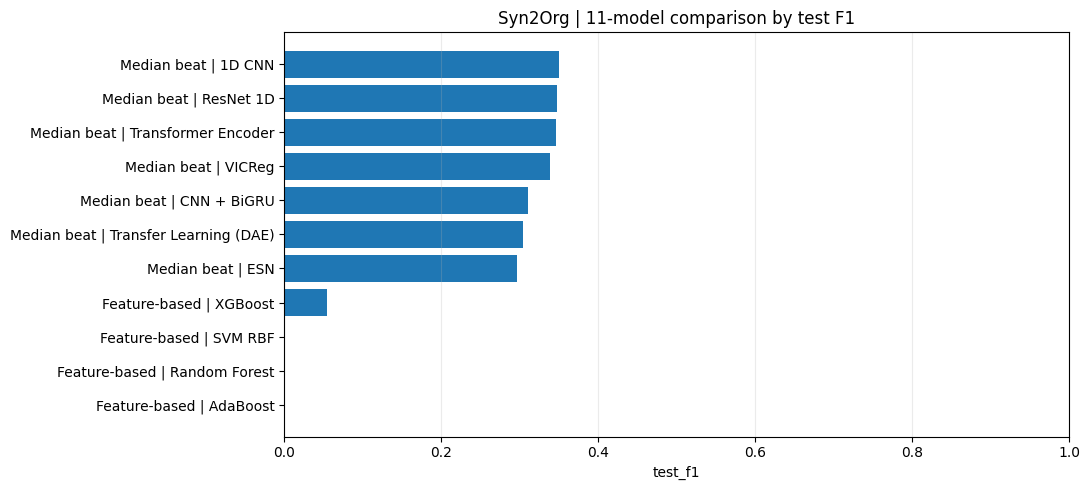

Saved plot: /kaggle/working/cross_domain_benchmark/plots/syn2org_11_model_comparison_by_test_auc__test_auc.png


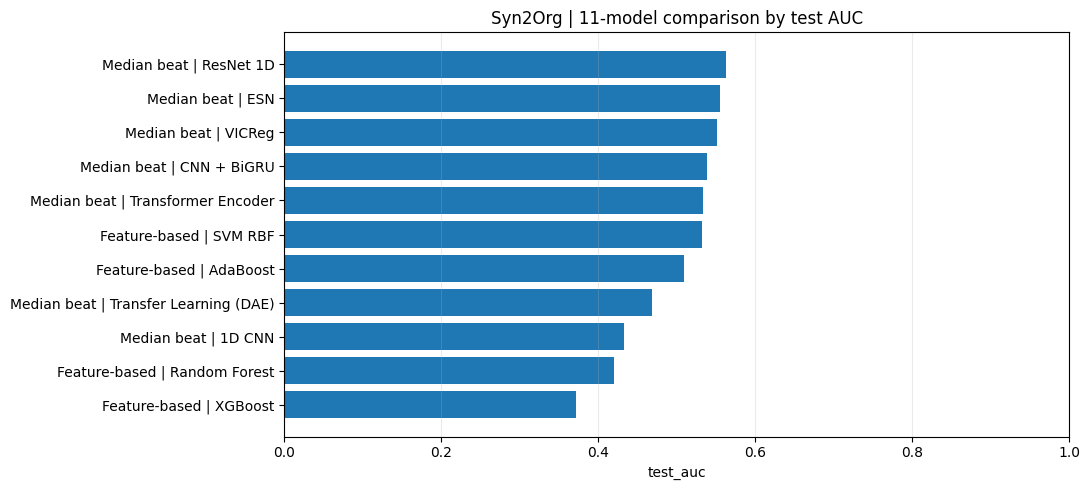

Saved plot: /kaggle/working/cross_domain_benchmark/plots/syn2org_average_score_by_representation__representation_summary.png
Saved table: /kaggle/working/cross_domain_benchmark/tables/syn2org_average_score_by_representation_representation_summary.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/syn2org_average_score_by_representation_representation_summary.json


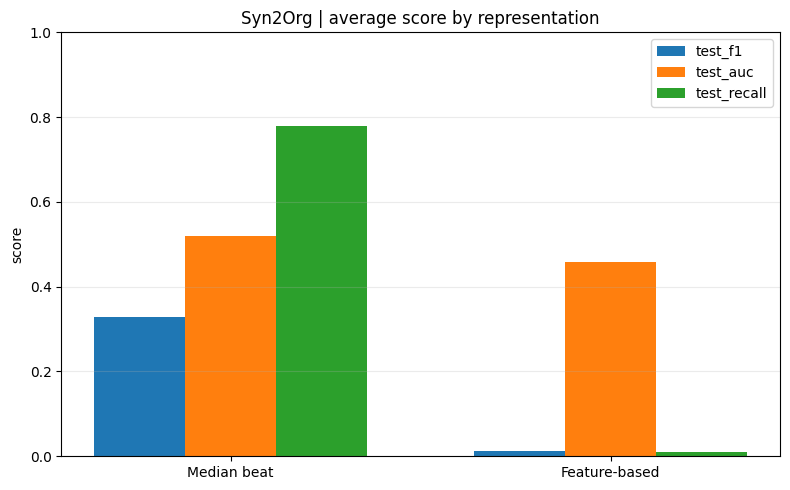

Saved plot: /kaggle/working/cross_domain_benchmark/plots/syn2org__best_training_curve_resnet_1d.png
Saved table: /kaggle/working/cross_domain_benchmark/histories/syn2org_resnet_1d_history.csv
Saved table: /kaggle/working/cross_domain_benchmark/histories/syn2org_resnet_1d_history.json


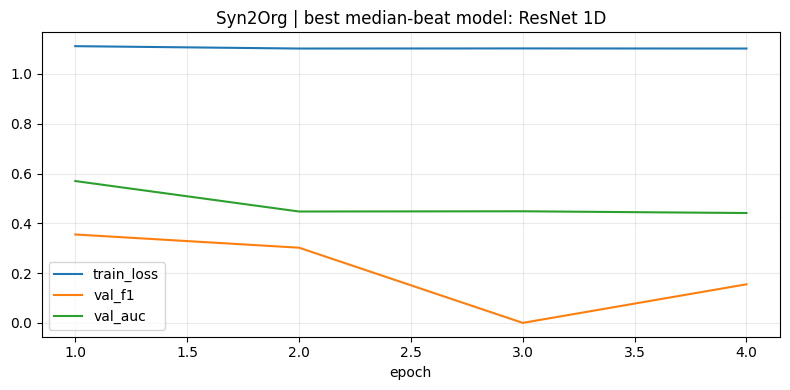

Saved table: /kaggle/working/cross_domain_benchmark/tables/syn2org_results_all.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/syn2org_results_all.json
Saved table: /kaggle/working/cross_domain_benchmark/tables/syn2org_feature_results.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/syn2org_feature_results.json
Saved table: /kaggle/working/cross_domain_benchmark/tables/syn2org_sequence_results.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/syn2org_sequence_results.json
Saved table: /kaggle/working/cross_domain_benchmark/histories/syn2org_1d_cnn_history.csv
Saved table: /kaggle/working/cross_domain_benchmark/histories/syn2org_1d_cnn_history.json
Saved table: /kaggle/working/cross_domain_benchmark/histories/syn2org_resnet_1d_history.csv
Saved table: /kaggle/working/cross_domain_benchmark/histories/syn2org_resnet_1d_history.json
Saved table: /kaggle/working/cross_domain_benchmark/histories/syn2org_cnn_bigru_history.csv
Saved table: /kaggle/work

{'csv': '/kaggle/working/cross_domain_benchmark/tables/syn2org_test_split.csv',
 'json': '/kaggle/working/cross_domain_benchmark/tables/syn2org_test_split.json'}

In [17]:
if "syn2org_split" not in globals() or "org2syn_split" not in globals():
    df_org = load_original_metadata(CONFIG)
    df_syn = load_synthetic_metadata(CONFIG)
    synthetic_train_df, synthetic_val_df, synthetic_test_df = split_synthetic_dev_test(df_syn, CONFIG)
    syn2org_split = make_synthetic_to_original_split(
        synthetic_train_df=synthetic_train_df,
        synthetic_val_df=synthetic_val_df,
        original_test_df=df_org,
    )
    org2syn_split = make_original_to_synthetic_split(
        df_org=df_org,
        synthetic_test_df=synthetic_test_df,
        config=CONFIG,
    )
    SCENARIO_SYN2ORG = "Syn2Org"
    SCENARIO_ORG2SYN = "Org2Syn"

ids_tr, Xf_tr, Xs_tr, y_tr = build_representations(syn2org_split.train_df, "synthetic", CONFIG)
ids_va, Xf_va, Xs_va, y_va = build_representations(syn2org_split.val_df, "synthetic", CONFIG)
ids_te, Xf_te, Xs_te, y_te = build_representations(syn2org_split.test_df, "original", CONFIG)

feature_results_syn, fitted_feature_models_syn = train_and_evaluate_feature_models(
    Xf_tr, y_tr, Xf_va, y_va, Xf_te, y_te
)
feature_results_syn = add_result_metadata(feature_results_syn, "Feature-based", SCENARIO_SYN2ORG)

sequence_results_syn, fitted_sequence_models_syn, sequence_histories_syn = train_and_evaluate_sequence_models(
    Xs_tr, y_tr, Xs_va, y_va, Xs_te, y_te, CONFIG
)
sequence_results_syn = add_result_metadata(sequence_results_syn, "Median beat", SCENARIO_SYN2ORG)

results_syn_all = pd.concat([feature_results_syn, sequence_results_syn], ignore_index=True)
results_syn_all = results_syn_all.sort_values(["test_f1", "test_auc"], ascending=False).reset_index(drop=True)

display(results_syn_all)

plot_model_comparison(
    results_syn_all,
    title="Syn2Org | 11-model comparison by test F1",
    metric="test_f1",
)
plot_model_comparison(
    results_syn_all,
    title="Syn2Org | 11-model comparison by test AUC",
    metric="test_auc",
)
plot_representation_summary(
    results_syn_all,
    title="Syn2Org | average score by representation",
)
plot_best_training_curve(
    sequence_histories_syn,
    title="Syn2Org",
)


save_dataframe_outputs(results_syn_all, "syn2org_results_all")
save_dataframe_outputs(feature_results_syn, "syn2org_feature_results")
save_dataframe_outputs(sequence_results_syn, "syn2org_sequence_results")
save_history_bundle(sequence_histories_syn, "syn2org")
save_dataframe_outputs(syn2org_split.train_df, "syn2org_train_split")
save_dataframe_outputs(syn2org_split.val_df, "syn2org_val_split")
save_dataframe_outputs(syn2org_split.test_df, "syn2org_test_split")


## 12. Run Org2Syn

[original] valid=344 | skipped=0
[original] valid=19 | skipped=0
[synthetic] valid=363 | skipped=0
Training feature model: XGBoost
Training feature model: Random Forest
Training feature model: SVM RBF
Training feature model: AdaBoost
Training median-beat model: 1D CNN
Training median-beat model: ResNet 1D
Training median-beat model: CNN + BiGRU
Training median-beat model: Transformer Encoder
Training median-beat model: Transfer Learning (DAE)
Training median-beat model: VICReg
Training median-beat model: ESN


,model,val_f1,val_recall,val_auc,test_f1,test_recall,test_auc,representation,scenario
0,CNN + BiGRU,0.421053,1.00,0.666667,0.344988,0.986667,0.483843,Median beat,Org2Syn
1,ResNet 1D,0.347826,1.00,0.633333,0.342466,1.000000,0.505602,Median beat,Org2Syn
2,Transformer Encoder,0.400000,0.50,0.666667,0.243902,0.400000,0.475231,Median beat,Org2Syn
3,1D CNN,0.545455,0.75,0.650000,0.236735,0.386667,0.454769,Median beat,Org2Syn
4,XGBoost,0.500000,0.50,0.883333,0.165517,0.160000,0.493241,Feature-based,Org2Syn
5,ESN,0.750000,0.75,0.983333,0.112150,0.080000,0.451111,Median beat,Org2Syn
6,SVM RBF,0.571429,0.50,0.850000,0.061224,0.040000,0.451806,Feature-based,Org2Syn
7,Transfer Learning (DAE),0.333333,0.25,0.650000,0.049383,0.026667,0.457685,Median beat,Org2Syn
8,AdaBoost,0.857143,0.75,0.850000,0.022989,0.013333,0.483866,Feature-based,Org2Syn
9,VICReg,0.000000,0.00,0.700000,0.000000,0.000000,0.469028,Median beat,Org2Syn


Saved plot: /kaggle/working/cross_domain_benchmark/plots/org2syn_11_model_comparison_by_test_f1__test_f1.png


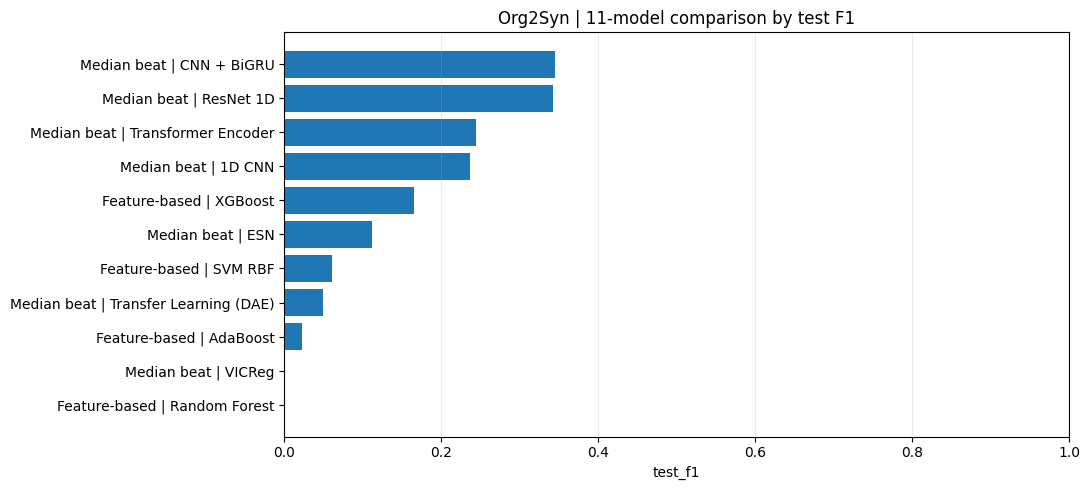

Saved plot: /kaggle/working/cross_domain_benchmark/plots/org2syn_11_model_comparison_by_test_auc__test_auc.png


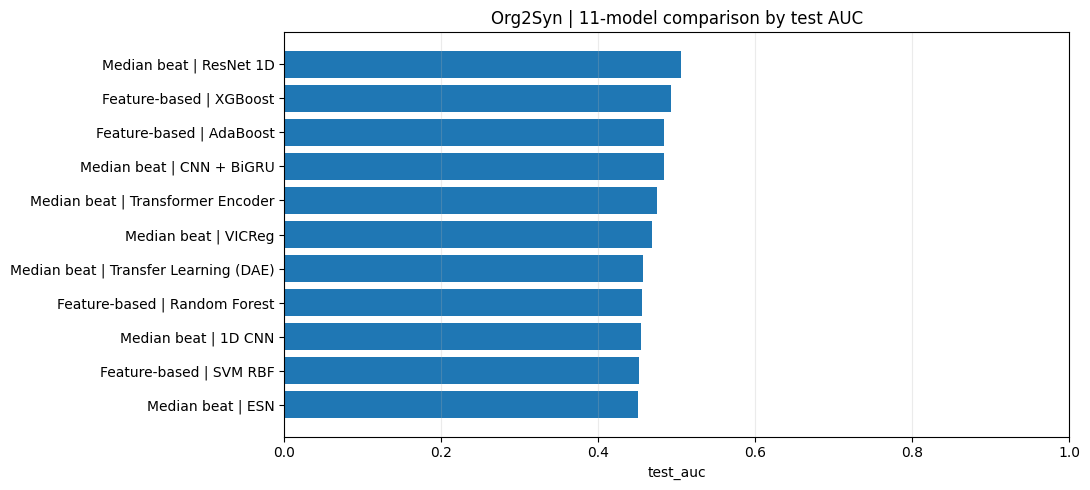

Saved plot: /kaggle/working/cross_domain_benchmark/plots/org2syn_average_score_by_representation__representation_summary.png
Saved table: /kaggle/working/cross_domain_benchmark/tables/org2syn_average_score_by_representation_representation_summary.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/org2syn_average_score_by_representation_representation_summary.json


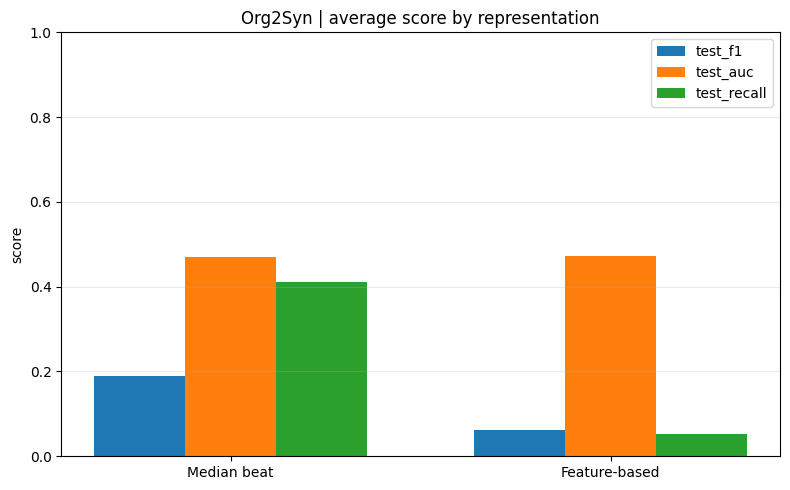

Saved plot: /kaggle/working/cross_domain_benchmark/plots/org2syn__best_training_curve_1d_cnn.png
Saved table: /kaggle/working/cross_domain_benchmark/histories/org2syn_1d_cnn_history.csv
Saved table: /kaggle/working/cross_domain_benchmark/histories/org2syn_1d_cnn_history.json


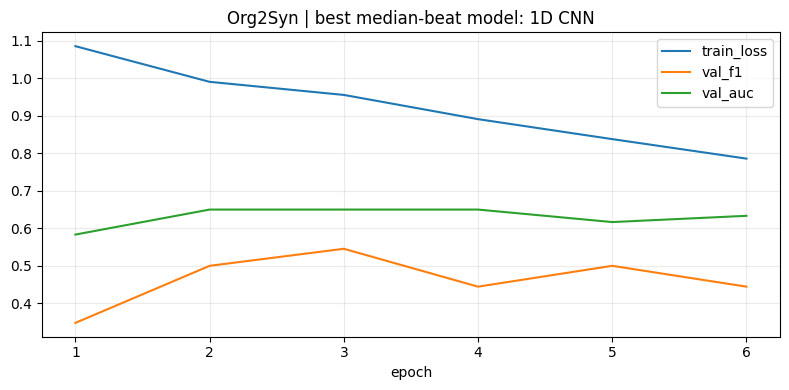

Saved table: /kaggle/working/cross_domain_benchmark/tables/org2syn_results_all.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/org2syn_results_all.json
Saved table: /kaggle/working/cross_domain_benchmark/tables/org2syn_feature_results.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/org2syn_feature_results.json
Saved table: /kaggle/working/cross_domain_benchmark/tables/org2syn_sequence_results.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/org2syn_sequence_results.json
Saved table: /kaggle/working/cross_domain_benchmark/histories/org2syn_1d_cnn_history.csv
Saved table: /kaggle/working/cross_domain_benchmark/histories/org2syn_1d_cnn_history.json
Saved table: /kaggle/working/cross_domain_benchmark/histories/org2syn_resnet_1d_history.csv
Saved table: /kaggle/working/cross_domain_benchmark/histories/org2syn_resnet_1d_history.json
Saved table: /kaggle/working/cross_domain_benchmark/histories/org2syn_cnn_bigru_history.csv
Saved table: /kaggle/work

{'csv': '/kaggle/working/cross_domain_benchmark/tables/org2syn_test_split.csv',
 'json': '/kaggle/working/cross_domain_benchmark/tables/org2syn_test_split.json'}

In [18]:
if "org2syn_split" not in globals():
    df_org = load_original_metadata(CONFIG)
    df_syn = load_synthetic_metadata(CONFIG)
    synthetic_train_df, synthetic_val_df, synthetic_test_df = split_synthetic_dev_test(df_syn, CONFIG)
    org2syn_split = make_original_to_synthetic_split(
        df_org=df_org,
        synthetic_test_df=synthetic_test_df,
        config=CONFIG,
    )
    SCENARIO_ORG2SYN = "Org2Syn"

ids_tr_o, Xf_tr_o, Xs_tr_o, y_tr_o = build_representations(org2syn_split.train_df, "original", CONFIG)
ids_va_o, Xf_va_o, Xs_va_o, y_va_o = build_representations(org2syn_split.val_df, "original", CONFIG)
ids_te_o, Xf_te_o, Xs_te_o, y_te_o = build_representations(org2syn_split.test_df, "synthetic", CONFIG)

feature_results_org, fitted_feature_models_org = train_and_evaluate_feature_models(
    Xf_tr_o, y_tr_o, Xf_va_o, y_va_o, Xf_te_o, y_te_o
)
feature_results_org = add_result_metadata(feature_results_org, "Feature-based", SCENARIO_ORG2SYN)

sequence_results_org, fitted_sequence_models_org, sequence_histories_org = train_and_evaluate_sequence_models(
    Xs_tr_o, y_tr_o, Xs_va_o, y_va_o, Xs_te_o, y_te_o, CONFIG
)
sequence_results_org = add_result_metadata(sequence_results_org, "Median beat", SCENARIO_ORG2SYN)

results_org_all = pd.concat([feature_results_org, sequence_results_org], ignore_index=True)
results_org_all = results_org_all.sort_values(["test_f1", "test_auc"], ascending=False).reset_index(drop=True)

display(results_org_all)

plot_model_comparison(
    results_org_all,
    title="Org2Syn | 11-model comparison by test F1",
    metric="test_f1",
)
plot_model_comparison(
    results_org_all,
    title="Org2Syn | 11-model comparison by test AUC",
    metric="test_auc",
)
plot_representation_summary(
    results_org_all,
    title="Org2Syn | average score by representation",
)
plot_best_training_curve(
    sequence_histories_org,
    title="Org2Syn",
)


save_dataframe_outputs(results_org_all, "org2syn_results_all")
save_dataframe_outputs(feature_results_org, "org2syn_feature_results")
save_dataframe_outputs(sequence_results_org, "org2syn_sequence_results")
save_history_bundle(sequence_histories_org, "org2syn")
save_dataframe_outputs(org2syn_split.train_df, "org2syn_train_split")
save_dataframe_outputs(org2syn_split.val_df, "org2syn_val_split")
save_dataframe_outputs(org2syn_split.test_df, "org2syn_test_split")


## 13. Global Summary

,model,val_f1,val_recall,val_auc,test_f1,test_recall,test_auc,representation,scenario
0,CNN + BiGRU,0.421053,1.000000,0.666667,0.344988,0.986667,0.483843,Median beat,Org2Syn
1,ResNet 1D,0.347826,1.000000,0.633333,0.342466,1.000000,0.505602,Median beat,Org2Syn
2,Transformer Encoder,0.400000,0.500000,0.666667,0.243902,0.400000,0.475231,Median beat,Org2Syn
3,1D CNN,0.545455,0.750000,0.650000,0.236735,0.386667,0.454769,Median beat,Org2Syn
4,XGBoost,0.500000,0.500000,0.883333,0.165517,0.160000,0.493241,Feature-based,Org2Syn
5,ESN,0.750000,0.750000,0.983333,0.112150,0.080000,0.451111,Median beat,Org2Syn
6,SVM RBF,0.571429,0.500000,0.850000,0.061224,0.040000,0.451806,Feature-based,Org2Syn
7,Transfer Learning (DAE),0.333333,0.250000,0.650000,0.049383,0.026667,0.457685,Median beat,Org2Syn
8,AdaBoost,0.857143,0.750000,0.850000,0.022989,0.013333,0.483866,Feature-based,Org2Syn
9,VICReg,0.000000,0.000000,0.700000,0.000000,0.000000,0.469028,Median beat,Org2Syn


Saved plot: /kaggle/working/cross_domain_benchmark/plots/all_scenarios_11_model_comparison_by_test_f1__test_f1.png


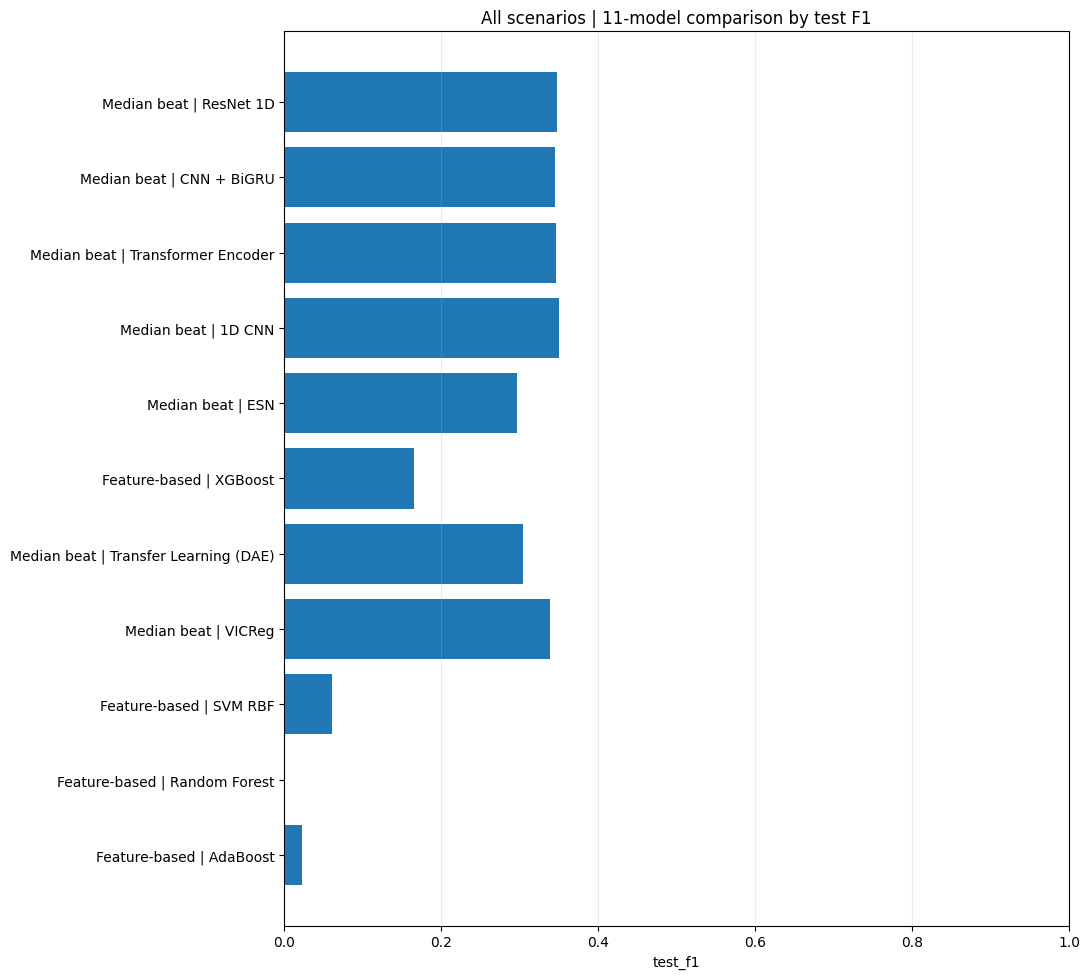

Saved table: /kaggle/working/cross_domain_benchmark/tables/all_scenarios_results.csv
Saved table: /kaggle/working/cross_domain_benchmark/tables/all_scenarios_results.json


{'csv': '/kaggle/working/cross_domain_benchmark/tables/all_scenarios_results.csv',
 'json': '/kaggle/working/cross_domain_benchmark/tables/all_scenarios_results.json'}

In [19]:

all_results = pd.concat([results_syn_all, results_org_all], ignore_index=True)
display(all_results.sort_values(["scenario", "test_f1", "test_auc"], ascending=[True, False, False]).reset_index(drop=True))

plot_model_comparison(
    all_results,
    title="All scenarios | 11-model comparison by test F1",
    metric="test_f1",
)


save_dataframe_outputs(all_results, "all_scenarios_results")
